<a href="https://colab.research.google.com/github/VivekChaurasiya95/DecodeLabs-Internship/blob/main/Decodelabs_Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3: Unsupervised Learning (Customer Segmentation)

## PART 1 : Import Libraries & Load Dataset

In [1]:
# ============================================================
# PROJECT 3
# CUSTOMER SEGMENTATION USING PCA + K-MEANS CLUSTERING
# ============================================================

# -------------------------------
# Import Libraries
# -------------------------------

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

plt.style.use("ggplot")
sns.set(font_scale=1.1)

print("Libraries Imported Successfully")

Libraries Imported Successfully


#### Load Dataset



In [2]:
# Upload dataset

from google.colab import files

uploaded = files.upload()

Saving Online_Retail.csv to Online_Retail.csv


#### Read Dataset

In [3]:
# Read CSV

df = pd.read_csv("Online_Retail.csv",encoding='ISO-8859-1')

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


#### Display Dataset

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


#### Shape

In [5]:
print("Rows :",df.shape[0])
print("Columns :",df.shape[1])

Rows : 541909
Columns : 8


#### Column Names

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

#### Data Types

In [7]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


#### Dataset Information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


#### Statistical Summary

In [9]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


#### Missing Values

In [10]:
missing=df.isnull().sum()

missing=missing[missing>0]

missing.sort_values(ascending=False)

,0
CustomerID,135080
Description,1454


#### Missing Value Percentage

In [11]:
missing_percent=100*df.isnull().sum()/len(df)

missing_percent=missing_percent[missing_percent>0]

missing_percent.sort_values(ascending=False)

,0
CustomerID,24.926694
Description,0.268311


#### Duplicate Rows

In [12]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 5268


#### Display Random Rows

In [13]:
df.sample(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
398571,571246,22998,TRAVEL CARD WALLET KEEP CALM,72,10/14/11 15:59,0.42,17750.0,United Kingdom
434315,574038,23284,DOORMAT KEEP CALM AND COME IN,2,11/2/11 12:56,8.25,18164.0,United Kingdom
82247,543193,21534,DAIRY MAID LARGE MILK JUG,6,2/4/11 12:18,4.95,13725.0,United Kingdom
282469,561651,85032B,BLOSSOM IMAGES GIFT WRAP SET,1,7/28/11 15:36,1.63,NaN,United Kingdom
121766,546782,84406B,CREAM CUPID HEARTS COAT HANGER,8,3/17/11 9:13,4.15,15291.0,United Kingdom
76703,542646,22937,BAKING MOULD CHOCOLATE CUPCAKES,6,1/31/11 11:42,2.55,17220.0,United Kingdom
150944,549525,22606,WOODEN SKITTLES GARDEN SET,1,4/8/11 15:44,33.29,NaN,United Kingdom
165350,550784,23201,JUMBO BAG ALPHABET,10,4/20/11 13:59,2.08,13269.0,United Kingdom
535521,581217,21981,PACK OF 12 WOODLAND TISSUES,1,12/8/11 9:20,0.83,NaN,United Kingdom
202922,554511,22851,SET 20 NAPKINS FAIRY CAKES DESIGN,3,5/24/11 15:52,1.63,NaN,United Kingdom


#### First Look at Numerical Columns

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Quantity,541909.0,9.552250,218.081158,-80995.00,1.00,3.00,10.00,80995.0
UnitPrice,541909.0,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,15287.690570,1713.600303,12346.00,13953.00,15152.00,16791.00,18287.0


#### First Look at Categorical Columns

In [15]:
df.describe(include='object').T

,count,unique,top,freq
InvoiceNo,541909,25900,573585,1114
StockCode,541909,4070,85123A,2313
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369
InvoiceDate,541909,23260,10/31/11 14:41,1114
Country,541909,38,United Kingdom,495478


#### Check Unique Values

In [16]:
for col in df.columns:
    print(col," : ",df[col].nunique())

InvoiceNo  :  25900
StockCode  :  4070
Description  :  4223
Quantity  :  722
InvoiceDate  :  23260
UnitPrice  :  1630
CustomerID  :  4372
Country  :  38


#### Invoice Date Conversion

In [17]:
df["InvoiceDate"]=pd.to_datetime(df["InvoiceDate"])

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


#### Check Date Range

In [19]:
print("Minimum Date :",df["InvoiceDate"].min())

print("Maximum Date :",df["InvoiceDate"].max())

Minimum Date : 2010-12-01 08:26:00
Maximum Date : 2011-12-09 12:50:00


## PART 2: Data Cleaning & Customer Feature Engineering

#### Check Dataset Before Cleaning

In [20]:

print("Dataset Shape Before Cleaning:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape Before Cleaning: (541909, 8)

Missing Values:

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268


#### Remove Missing Customer IDs

In [21]:

df = df.dropna(subset=["CustomerID"])

print("Shape after removing missing CustomerID:", df.shape)

Shape after removing missing CustomerID: (406829, 8)


#### Remove Duplicate Rows

In [22]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate Records: 5225
Shape after removing duplicates: (401604, 8)


#### Remove Cancelled Orders

In [23]:
print("Invoices before removing cancellations:", df.shape[0])

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

print("Invoices after removing cancellations:", df.shape[0])

Invoices before removing cancellations: 401604
Invoices after removing cancellations: 392732


#### Remove Invalid Quantities

In [24]:

df = df[df["Quantity"] > 0]

print("Shape:", df.shape)

Shape: (392732, 8)


#### Remove Invalid Unit Prices

In [25]:

df = df[df["UnitPrice"] > 0]

print("Shape:", df.shape)

Shape: (392692, 8)


#### Create Total Price

In [26]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#### Check Numerical Statistics

In [27]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,392692.0,13.119702,1.0,2.0,6.0,12.0,80995.0,180.492832
InvoiceDate,392692,2011-07-10 19:13:07.771892480,2010-12-01 08:26:00,2011-04-07 11:12:00,2011-07-31 12:02:00,2011-10-20 12:53:00,2011-12-09 12:50:00,NaN
UnitPrice,392692.0,3.125914,0.001,1.25,1.95,3.75,8142.75,22.241836
CustomerID,392692.0,15287.843865,12346.0,13955.0,15150.0,16791.0,18287.0,1713.539549
TotalPrice,392692.0,22.6315,0.001,4.95,12.45,19.8,168469.6,311.099224


#### Remove Extreme Outliers (IQR Method)

In [28]:
def remove_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data = data[(data[column] >= lower) &
                (data[column] <= upper)]

    return data

In [29]:
columns = ["Quantity","UnitPrice","TotalPrice"]

for col in columns:
    df = remove_outliers(df,col)

print(df.shape)

(319806, 9)


#### Verify Dataset

In [30]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [31]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,319806.0,7.141748,1.0,2.0,5.0,12.0,27.0,6.493338
InvoiceDate,319806,2011-07-12 15:46:29.448415232,2010-12-01 08:26:00,2011-04-08 09:45:00,2011-08-03 12:10:00,2011-10-23 12:46:00,2011-12-09 12:50:00,NaN
UnitPrice,319806.0,2.125062,0.001,0.95,1.65,2.95,7.5,1.500825
CustomerID,319806.0,15331.785501,12347.0,14002.0,15256.0,16837.0,18287.0,1709.821705
TotalPrice,319806.0,10.961622,0.001,3.75,9.9,16.5,37.5,8.232676


#### Create Customer-Level Dataset (RFM)

In [32]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

#### Calculate RFM Features

In [33]:
customer_df = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (reference_date - x.max()).days,

    "InvoiceNo": "nunique",

    "TotalPrice": "sum"

})

customer_df.columns = ["Recency","Frequency","Monetary"]

customer_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,2,7,2783.37
12348.0,249,3,90.20
12349.0,19,1,939.75
12350.0,310,1,294.40
12352.0,36,7,1130.94


#### Additional Customer Features

In [34]:
customer_features = df.groupby("CustomerID").agg(

    AvgQuantity=("Quantity","mean"),

    MaxQuantity=("Quantity","max"),

    MinQuantity=("Quantity","min"),

    AvgUnitPrice=("UnitPrice","mean"),

    MaxUnitPrice=("UnitPrice","max"),

    MinUnitPrice=("UnitPrice","min"),

    AvgTransactionValue=("TotalPrice","mean"),

    MaxTransactionValue=("TotalPrice","max"),

    TotalItems=("Quantity","sum"),

    UniqueProducts=("StockCode","nunique"),

    UniqueInvoices=("InvoiceNo","nunique"),

    PurchaseStd=("TotalPrice","std")

)

customer_features.head()

,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
CustomerID,,,,,,,,,,,,
12347.0,10.974194,24,3,2.300903,5.95,0.25,17.957226,35.70,1701,93,7,7.068553
12348.0,23.333333,24,20,0.650000,0.85,0.55,15.033333,20.40,140,6,3,3.036884
12349.0,8.964912,25,2,2.566667,7.50,0.42,16.486842,27.04,511,57,1,4.725995
12350.0,12.250000,24,6,1.581250,2.95,0.85,18.400000,25.20,196,16,1,5.214211
12352.0,7.575758,16,2,3.125152,6.25,0.65,17.135455,35.70,500,49,7,3.703872


#### Merge All Features

In [35]:
customer_df = customer_df.join(customer_features)

customer_df.head()

,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
CustomerID,,,,,,,,,,,,,,,
12347.0,2,7,2783.37,10.974194,24,3,2.300903,5.95,0.25,17.957226,35.70,1701,93,7,7.068553
12348.0,249,3,90.20,23.333333,24,20,0.650000,0.85,0.55,15.033333,20.40,140,6,3,3.036884
12349.0,19,1,939.75,8.964912,25,2,2.566667,7.50,0.42,16.486842,27.04,511,57,1,4.725995
12350.0,310,1,294.40,12.250000,24,6,1.581250,2.95,0.85,18.400000,25.20,196,16,1,5.214211
12352.0,36,7,1130.94,7.575758,16,2,3.125152,6.25,0.65,17.135455,35.70,500,49,7,3.703872


#### Handle Missing Values

In [36]:
customer_df.fillna(0,inplace=True)

customer_df.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
AvgQuantity,0
MaxQuantity,0
MinQuantity,0
AvgUnitPrice,0
MaxUnitPrice,0
MinUnitPrice,0
AvgTransactionValue,0


#### Check Final Dataset

In [37]:
print("Customer Dataset Shape:", customer_df.shape)

customer_df.head()

Customer Dataset Shape: (4146, 15)


,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
CustomerID,,,,,,,,,,,,,,,
12347.0,2,7,2783.37,10.974194,24,3,2.300903,5.95,0.25,17.957226,35.70,1701,93,7,7.068553
12348.0,249,3,90.20,23.333333,24,20,0.650000,0.85,0.55,15.033333,20.40,140,6,3,3.036884
12349.0,19,1,939.75,8.964912,25,2,2.566667,7.50,0.42,16.486842,27.04,511,57,1,4.725995
12350.0,310,1,294.40,12.250000,24,6,1.581250,2.95,0.85,18.400000,25.20,196,16,1,5.214211
12352.0,36,7,1130.94,7.575758,16,2,3.125152,6.25,0.65,17.135455,35.70,500,49,7,3.703872


#### Dataset Information

In [38]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4146 entries, 12347.0 to 18287.0
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Recency              4146 non-null   int64  
 1   Frequency            4146 non-null   int64  
 2   Monetary             4146 non-null   float64
 3   AvgQuantity          4146 non-null   float64
 4   MaxQuantity          4146 non-null   int64  
 5   MinQuantity          4146 non-null   int64  
 6   AvgUnitPrice         4146 non-null   float64
 7   MaxUnitPrice         4146 non-null   float64
 8   MinUnitPrice         4146 non-null   float64
 9   AvgTransactionValue  4146 non-null   float64
 10  MaxTransactionValue  4146 non-null   float64
 11  TotalItems           4146 non-null   int64  
 12  UniqueProducts       4146 non-null   int64  
 13  UniqueInvoices       4146 non-null   int64  
 14  PurchaseStd          4146 non-null   float64
dtypes: float64(8), int64(7)
memory usa

#### Statistical Summary

In [39]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4146.0,93.181380,100.015984,1.000000,18.000000,51.000000,145.000000,374.000000
Frequency,4146.0,3.918234,6.813902,1.000000,1.000000,2.000000,4.000000,193.000000
Monetary,4146.0,845.536065,1761.718973,1.700000,171.970000,402.440000,957.142500,70372.020000
AvgQuantity,4146.0,8.813391,4.381211,1.000000,5.174408,9.127016,11.520615,25.000000
MaxQuantity,4146.0,20.525808,6.246248,1.000000,16.000000,24.000000,25.000000,27.000000
MinQuantity,4146.0,2.982393,3.140295,1.000000,1.000000,2.000000,3.000000,25.000000
AvgUnitPrice,4146.0,2.209538,0.704582,0.240000,1.797422,2.150000,2.550000,7.500000
MaxUnitPrice,4146.0,5.486488,1.559421,0.290000,4.950000,5.950000,6.750000,7.500000
MinUnitPrice,4146.0,0.582435,0.632533,0.001000,0.290000,0.420000,0.650000,7.500000
AvgTransactionValue,4146.0,13.726180,5.874316,0.747143,8.718809,15.238370,17.451004,37.500000


## PART 3: Exploratory Data Analysis (EDA)

#### Check Customer Dataset

In [40]:
print("Customer Dataset Shape :", customer_df.shape)

customer_df.head()

Customer Dataset Shape : (4146, 15)


,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
CustomerID,,,,,,,,,,,,,,,
12347.0,2,7,2783.37,10.974194,24,3,2.300903,5.95,0.25,17.957226,35.70,1701,93,7,7.068553
12348.0,249,3,90.20,23.333333,24,20,0.650000,0.85,0.55,15.033333,20.40,140,6,3,3.036884
12349.0,19,1,939.75,8.964912,25,2,2.566667,7.50,0.42,16.486842,27.04,511,57,1,4.725995
12350.0,310,1,294.40,12.250000,24,6,1.581250,2.95,0.85,18.400000,25.20,196,16,1,5.214211
12352.0,36,7,1130.94,7.575758,16,2,3.125152,6.25,0.65,17.135455,35.70,500,49,7,3.703872


#### Dataset Information

In [41]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4146 entries, 12347.0 to 18287.0
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Recency              4146 non-null   int64  
 1   Frequency            4146 non-null   int64  
 2   Monetary             4146 non-null   float64
 3   AvgQuantity          4146 non-null   float64
 4   MaxQuantity          4146 non-null   int64  
 5   MinQuantity          4146 non-null   int64  
 6   AvgUnitPrice         4146 non-null   float64
 7   MaxUnitPrice         4146 non-null   float64
 8   MinUnitPrice         4146 non-null   float64
 9   AvgTransactionValue  4146 non-null   float64
 10  MaxTransactionValue  4146 non-null   float64
 11  TotalItems           4146 non-null   int64  
 12  UniqueProducts       4146 non-null   int64  
 13  UniqueInvoices       4146 non-null   int64  
 14  PurchaseStd          4146 non-null   float64
dtypes: float64(8), int64(7)
memory usa

#### Statistical Summary

In [42]:
customer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Recency,4146.0,93.181380,100.015984,1.000000,18.000000,51.000000,145.000000,374.000000
Frequency,4146.0,3.918234,6.813902,1.000000,1.000000,2.000000,4.000000,193.000000
Monetary,4146.0,845.536065,1761.718973,1.700000,171.970000,402.440000,957.142500,70372.020000
AvgQuantity,4146.0,8.813391,4.381211,1.000000,5.174408,9.127016,11.520615,25.000000
MaxQuantity,4146.0,20.525808,6.246248,1.000000,16.000000,24.000000,25.000000,27.000000
MinQuantity,4146.0,2.982393,3.140295,1.000000,1.000000,2.000000,3.000000,25.000000
AvgUnitPrice,4146.0,2.209538,0.704582,0.240000,1.797422,2.150000,2.550000,7.500000
MaxUnitPrice,4146.0,5.486488,1.559421,0.290000,4.950000,5.950000,6.750000,7.500000
MinUnitPrice,4146.0,0.582435,0.632533,0.001000,0.290000,0.420000,0.650000,7.500000
AvgTransactionValue,4146.0,13.726180,5.874316,0.747143,8.718809,15.238370,17.451004,37.500000


#### Check Missing Values

In [43]:
customer_df.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
AvgQuantity,0
MaxQuantity,0
MinQuantity,0
AvgUnitPrice,0
MaxUnitPrice,0
MinUnitPrice,0
AvgTransactionValue,0


#### Check Duplicate Customers

In [44]:
print("Duplicate Customers :", customer_df.duplicated().sum())

Duplicate Customers : 2


#### Distribution of Features

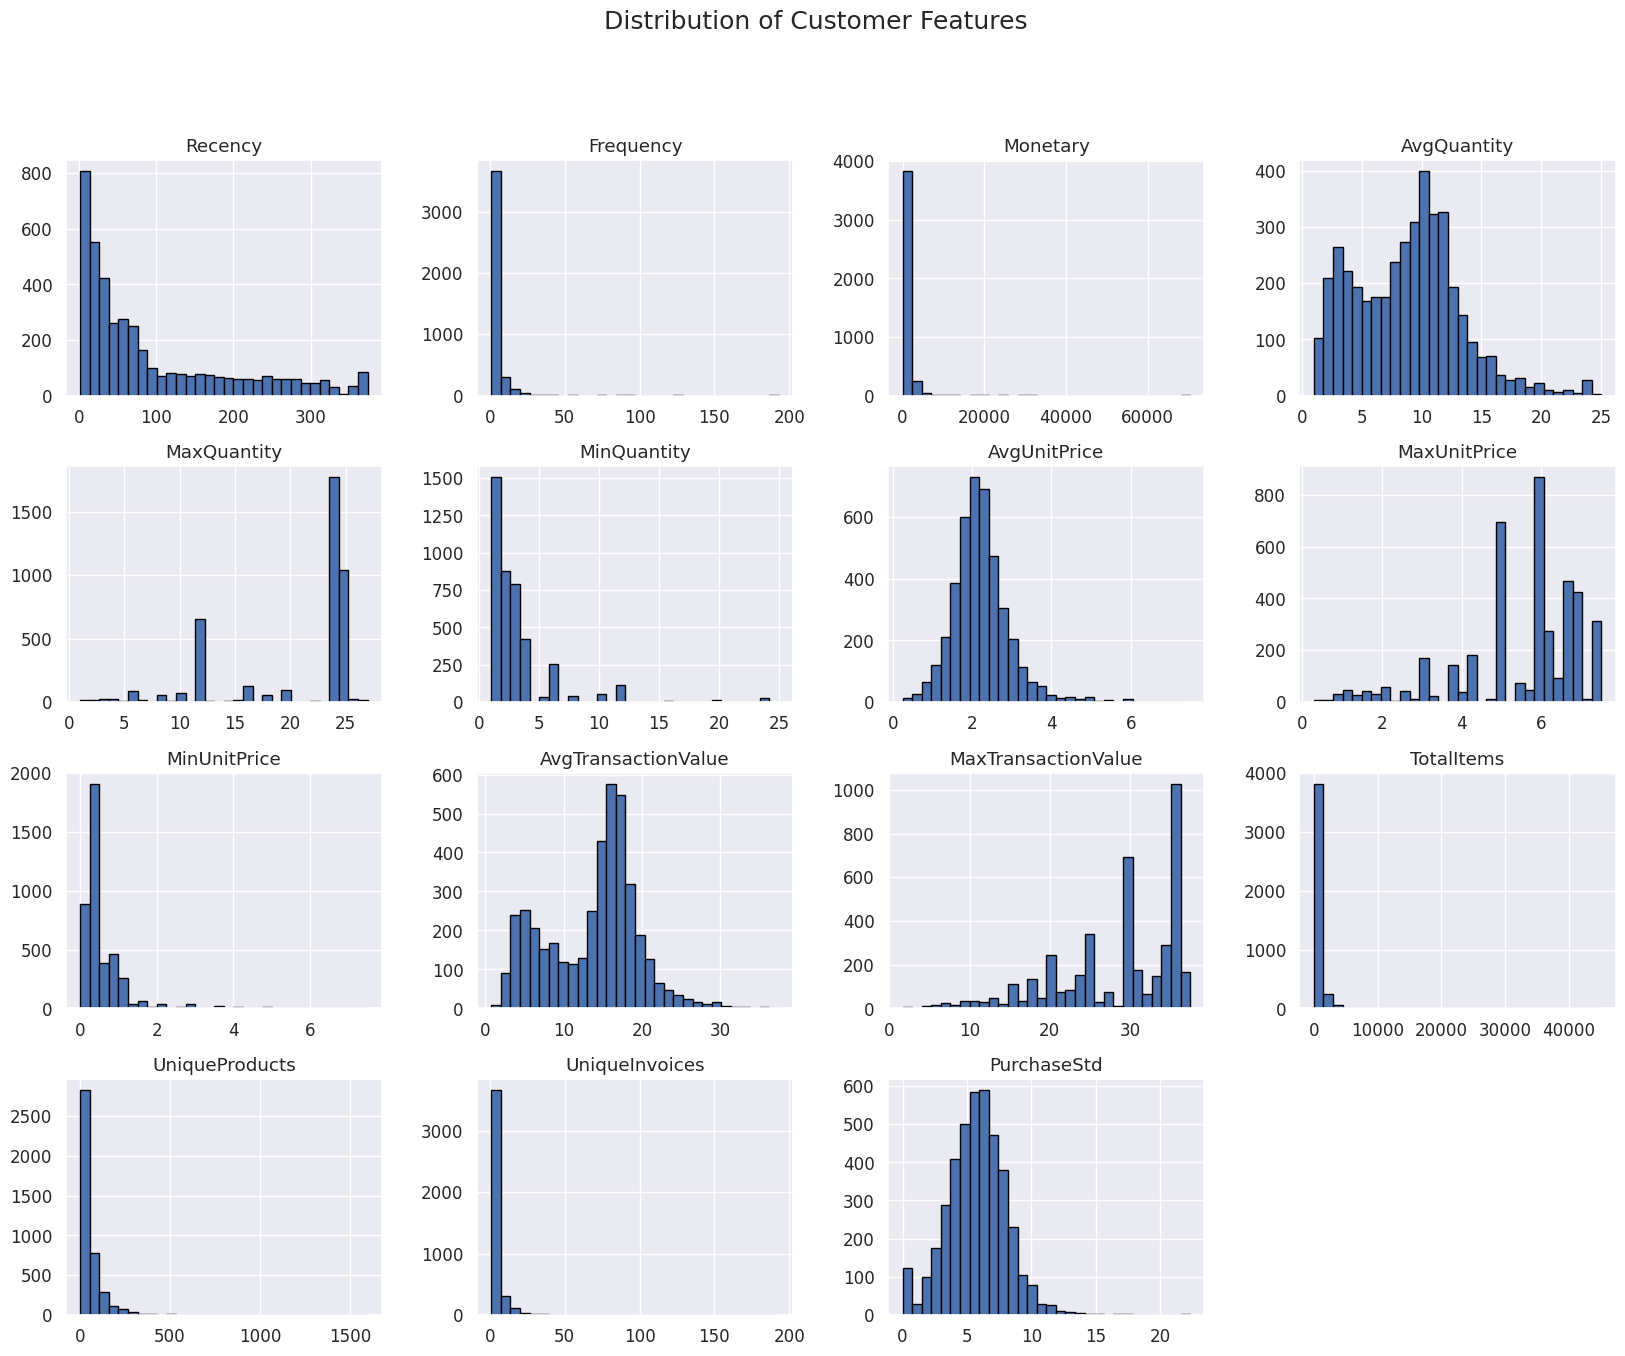

In [45]:
customer_df.hist(
    figsize=(20,15),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Distribution of Customer Features", fontsize=18)
plt.show()

#### Boxplots

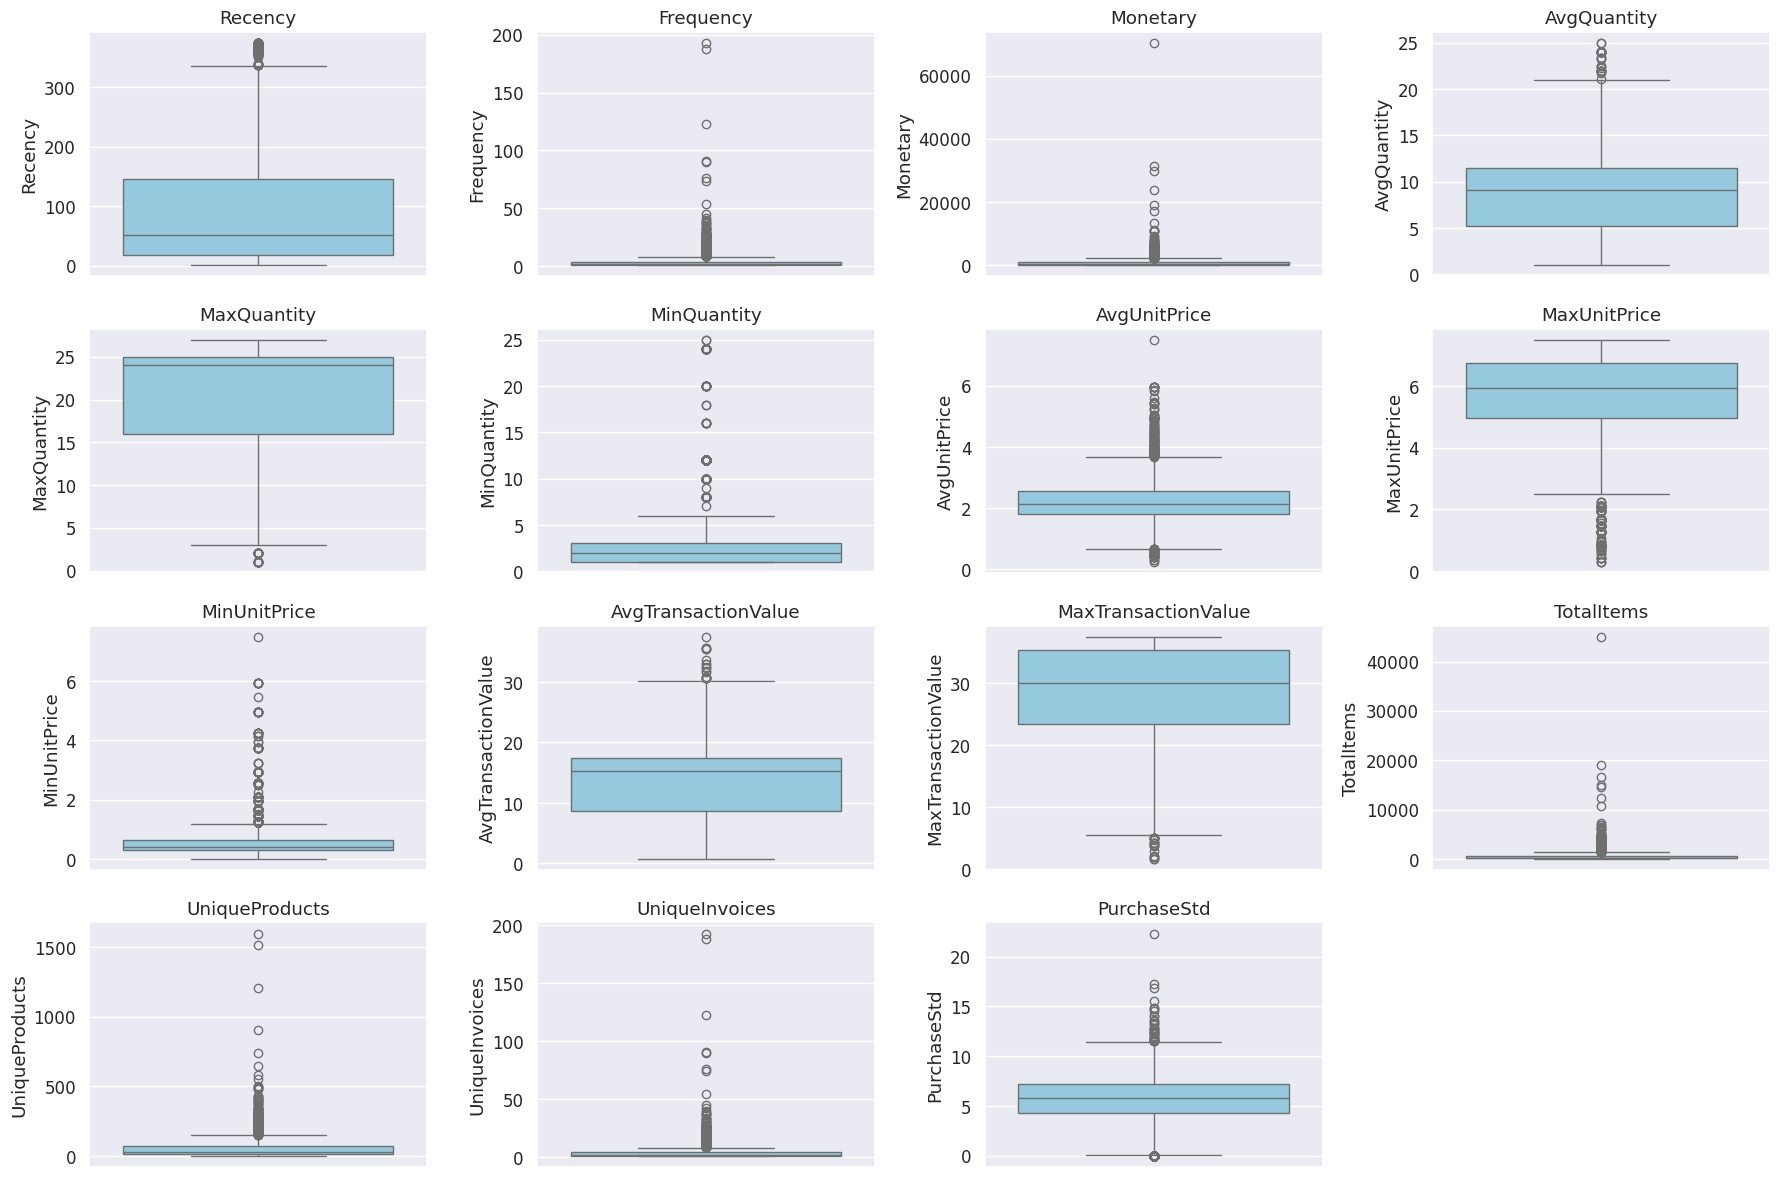

In [46]:
plt.figure(figsize=(18,12))

for i, col in enumerate(customer_df.columns):

    plt.subplot(4,4,i+1)

    sns.boxplot(y=customer_df[col], color="skyblue")

    plt.title(col)

plt.tight_layout()

plt.show()

#### Correlation Matrix

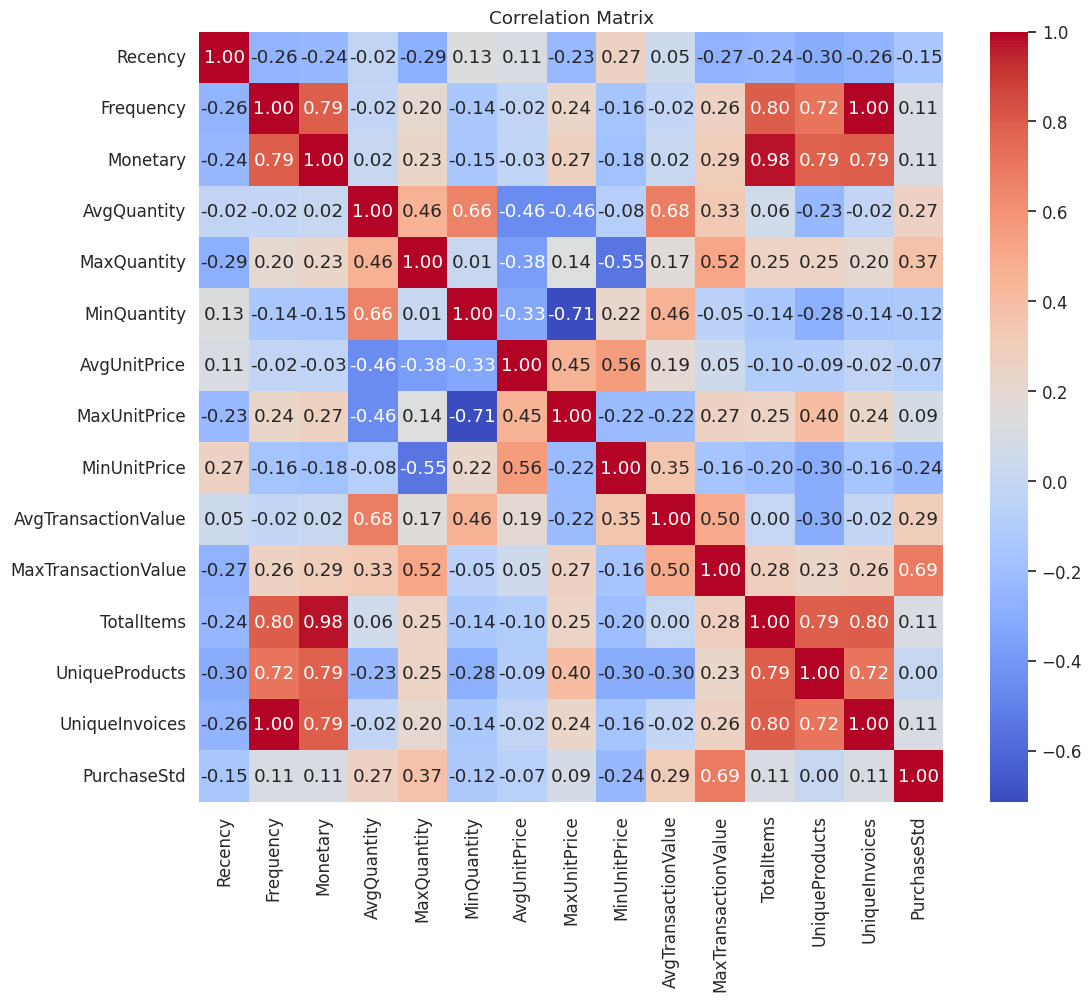

In [47]:
plt.figure(figsize=(12,10))

sns.heatmap(

    customer_df.corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Matrix")

plt.show()

#### Feature Correlation (Cleaner Heatmap)

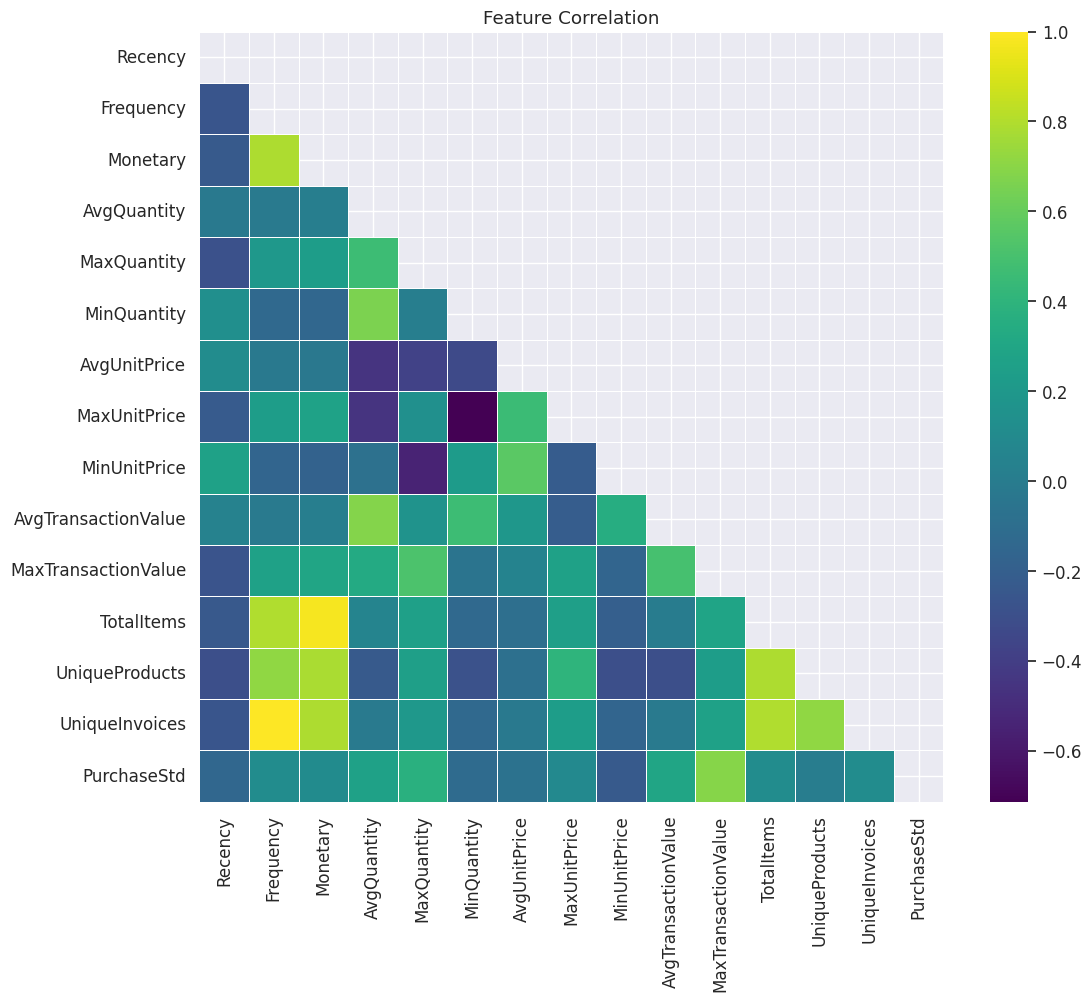

In [48]:
plt.figure(figsize=(12,10))

corr = customer_df.corr()

mask = np.triu(np.ones_like(corr,dtype=bool))

sns.heatmap(

    corr,

    mask=mask,

    cmap="viridis",

    annot=False,

    linewidths=0.5

)

plt.title("Feature Correlation")

plt.show()

#### Pairplot (Important Features)

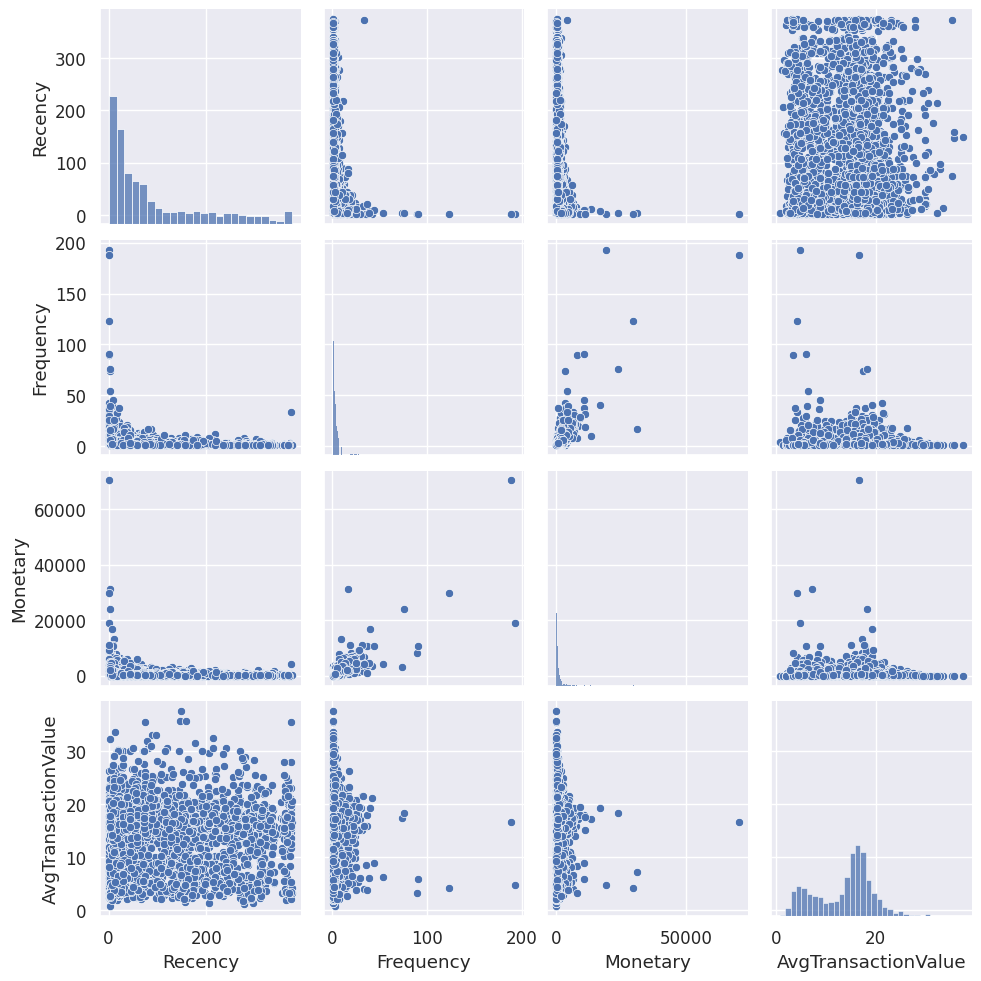

In [49]:
selected = customer_df[

    [

        "Recency",

        "Frequency",

        "Monetary",

        "AvgTransactionValue"

    ]

]

sns.pairplot(selected)

plt.show()

#### Customer Spending Distribution

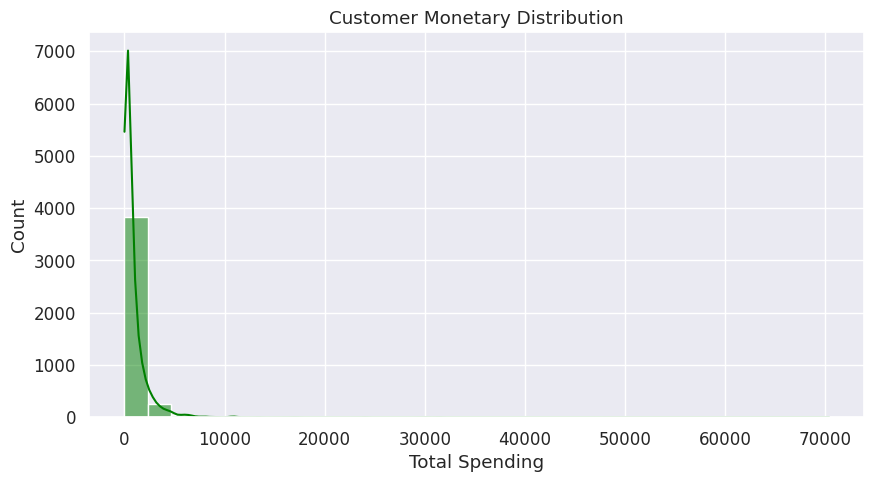

In [50]:
plt.figure(figsize=(10,5))

sns.histplot(

    customer_df["Monetary"],

    kde=True,

    bins=30,

    color="green"

)

plt.title("Customer Monetary Distribution")

plt.xlabel("Total Spending")

plt.show()

#### Purchase Frequency Distribution

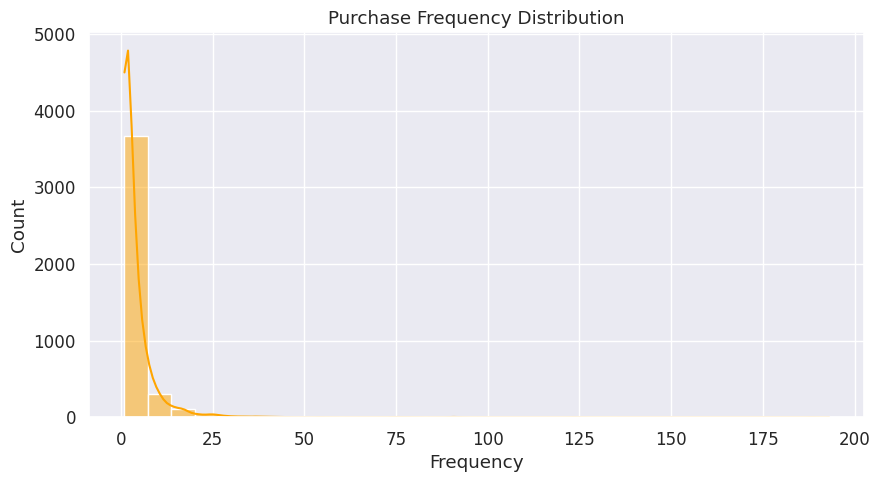

In [51]:
plt.figure(figsize=(10,5))

sns.histplot(

    customer_df["Frequency"],

    kde=True,

    bins=30,

    color="orange"

)

plt.title("Purchase Frequency Distribution")

plt.show()

#### Recency Distribution

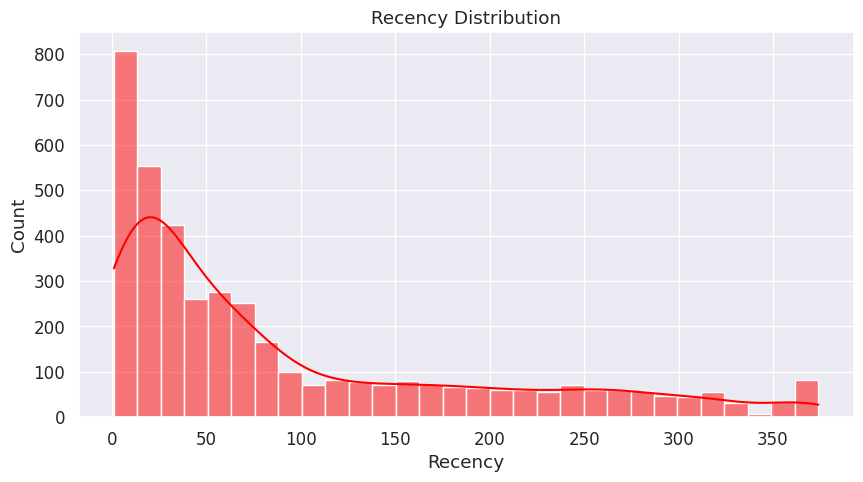

In [52]:
plt.figure(figsize=(10,5))

sns.histplot(

    customer_df["Recency"],

    kde=True,

    bins=30,

    color="red"

)

plt.title("Recency Distribution")

plt.show()

#### Top Spending Customers

In [53]:
top_customers = customer_df.sort_values(

    by="Monetary",

    ascending=False

).head(10)

top_customers

,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
CustomerID,,,,,,,,,,,,,,,
14911.0,1,188,70372.02,10.634947,25,1,2.293367,7.50,0.08,16.616770,37.50,45039,1511,188,6.736270
14096.0,4,17,31267.34,2.852323,26,1,2.978382,7.46,0.42,7.226101,37.35,12342,907,17,6.756144
17841.0,2,123,29748.94,2.641962,26,1,2.026390,7.50,0.12,4.144461,37.50,18964,1202,123,4.441452
13089.0,4,76,23921.16,12.758040,25,2,1.902266,7.50,0.19,18.316355,37.50,16662,492,76,8.496485
12748.0,1,193,19088.46,3.609604,27,1,1.943354,7.50,0.06,4.749555,37.44,14507,1596,193,5.207732
14298.0,8,40,16980.99,17.112756,27,1,1.400763,7.45,0.19,19.340535,37.50,15025,584,40,8.272944
13081.0,12,10,13196.03,13.959530,25,2,1.747376,6.95,0.19,17.227193,37.50,10693,407,10,8.105578
17735.0,2,19,11012.05,11.516026,24,1,1.897179,6.35,0.12,17.647516,35.70,7186,288,19,6.065944
14156.0,10,32,10923.13,8.588154,25,1,2.433567,7.50,0.12,15.045634,35.70,6235,480,32,7.706166


#### Bar Plot of Top Customers

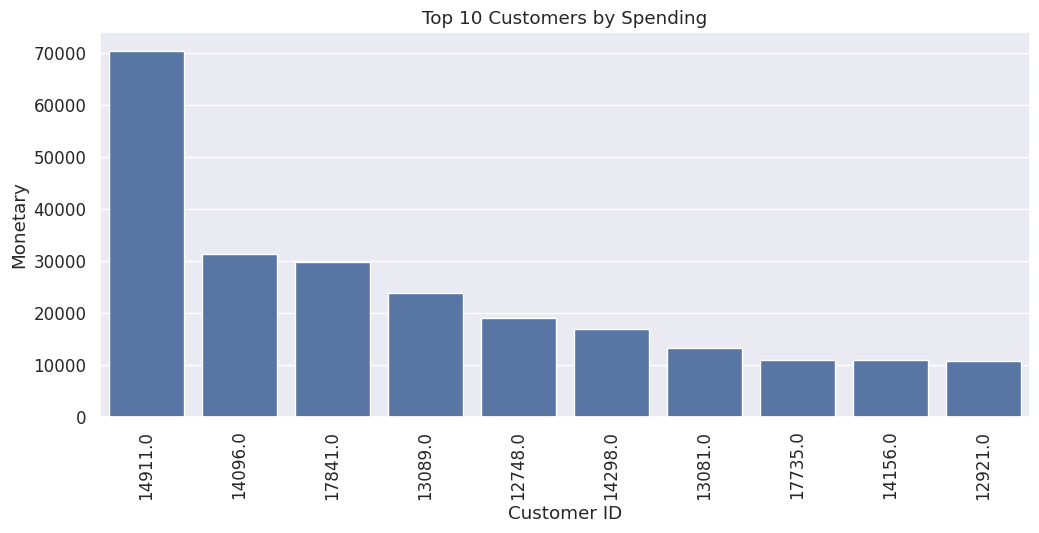

In [54]:
plt.figure(figsize=(12,5))

sns.barplot(

    x=top_customers.index.astype(str),

    y=top_customers["Monetary"]

)

plt.xticks(rotation=90)

plt.title("Top 10 Customers by Spending")

plt.xlabel("Customer ID")

plt.ylabel("Monetary")

plt.show()

#### Skewness

In [55]:
customer_df.skew().sort_values(ascending=False)

,0
Monetary,19.014973
TotalItems,18.200000
Frequency,13.737956
UniqueInvoices,13.737956
UniqueProducts,6.753167
MinUnitPrice,4.135491
MinQuantity,3.604338
Recency,1.235292
AvgUnitPrice,1.096667
AvgQuantity,0.447777


#### Kurtosis

In [56]:
customer_df.kurtosis().sort_values(ascending=False)

,0
Monetary,637.177786
TotalItems,600.960237
Frequency,313.848377
UniqueInvoices,313.848377
UniqueProducts,96.717449
MinUnitPrice,24.029616
MinQuantity,17.278243
AvgUnitPrice,3.945275
PurchaseStd,1.417779
MaxUnitPrice,0.654500


#### Covariance Matrix

In [57]:
customer_df.cov()

,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
Recency,10003.197009,-177.668157,-4.145183e+04,-9.137723,-182.140026,42.300179,7.778311,-35.154567,16.828856,27.119200,-206.877193,-2.745142e+04,-2290.960006,-177.668157,-33.710712
Frequency,-177.668157,46.429260,9.504793e+03,-0.456672,8.482328,-2.920861,-0.107353,2.509365,-0.700693,-0.674414,13.776880,6.192561e+03,370.315756,46.429260,1.745857
Monetary,-41451.825451,9504.793448,3.103654e+06,121.344034,2551.407598,-811.240899,-35.071844,743.530223,-202.661916,156.702397,3959.291566,1.968739e+06,104944.887255,9504.793448,443.004497
AvgQuantity,-9.137723,-0.456672,1.213440e+02,19.195012,12.602753,9.097616,-1.414535,-3.134600,-0.219641,17.494984,10.981113,3.108349e+02,-76.917527,-0.456672,2.695541
MaxQuantity,-182.140026,8.482328,2.551408e+03,12.602753,39.015618,0.230249,-1.650731,1.375427,-2.166898,6.195366,24.778997,1.814125e+03,116.958455,8.482328,5.362731
MinQuantity,42.300179,-2.920861,-8.112409e+02,9.097616,0.230249,9.861451,-0.725232,-3.493685,0.433761,8.526506,-1.224601,-4.862937e+02,-67.008400,-2.920861,-0.854090
AvgUnitPrice,7.778311,-0.107353,-3.507184e+01,-1.414535,-1.650731,-0.725232,0.496436,0.498532,0.249104,0.802447,0.272390,-7.793098e+01,-4.560018,-0.107353,-0.113626
MaxUnitPrice,-35.154567,2.509365,7.435302e+02,-3.134600,1.375427,-3.493685,0.498532,2.431793,-0.218292,-1.972946,3.225572,4.392247e+02,47.455780,2.509365,0.331395
MinUnitPrice,16.828856,-0.700693,-2.026619e+02,-0.219641,-2.166898,0.433761,0.249104,-0.218292,0.400098,1.304499,-0.767814,-1.450600e+02,-14.363471,-0.700693,-0.344257
AvgTransactionValue,27.119200,-0.674414,1.567024e+02,17.494984,6.195366,8.526506,0.802447,-1.972946,1.304499,34.507585,22.397295,1.179535e+01,-133.129941,-0.674414,3.962938


#### Scatter Plot (Frequency vs Monetary)

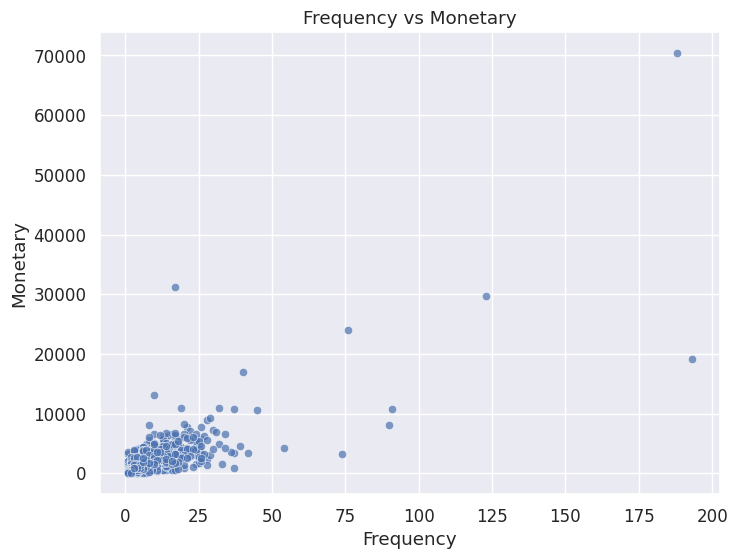

In [58]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x="Frequency",

    y="Monetary",

    data=customer_df,

    alpha=0.7

)

plt.title("Frequency vs Monetary")

plt.show()

#### Scatter Plot (Recency vs Monetary)

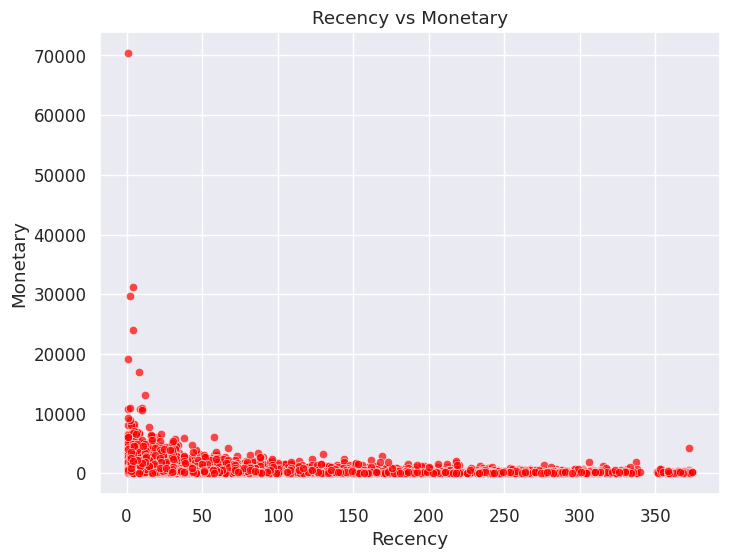

In [59]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x="Recency",

    y="Monetary",

    data=customer_df,

    alpha=0.7,

    color="red"

)

plt.title("Recency vs Monetary")

plt.show()

#### Scatter Plot (Recency vs Frequency)

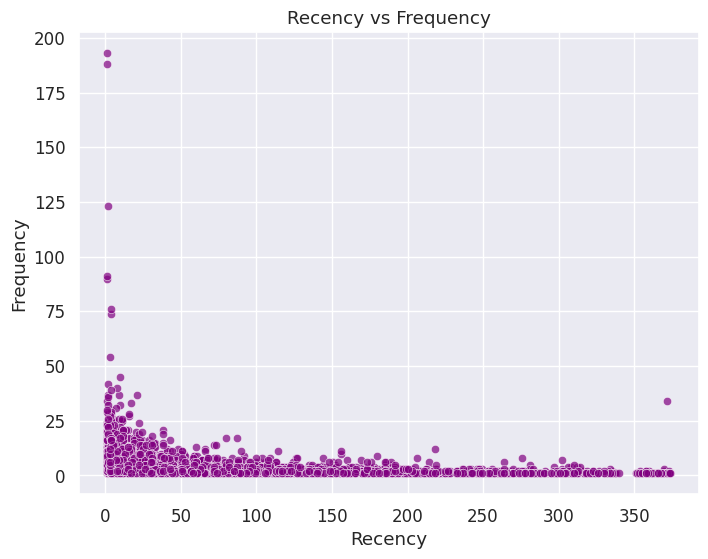

In [60]:
plt.figure(figsize=(8,6))

sns.scatterplot(

    x="Recency",

    y="Frequency",

    data=customer_df,

    alpha=0.7,

    color="purple"

)

plt.title("Recency vs Frequency")

plt.show()

#### Feature Means

In [61]:
customer_df.mean().sort_values(ascending=False)

,0
Monetary,845.536065
TotalItems,550.886155
Recency,93.181380
UniqueProducts,54.427159
MaxTransactionValue,28.321375
MaxQuantity,20.525808
AvgTransactionValue,13.726180
AvgQuantity,8.813391
PurchaseStd,5.733617
MaxUnitPrice,5.486488


#### Feature Variances

In [62]:
customer_df.var().sort_values(ascending=False)

,0
Monetary,3.103654e+06
TotalItems,1.301081e+06
Recency,1.000320e+04
UniqueProducts,5.747854e+03
MaxTransactionValue,5.872135e+01
UniqueInvoices,4.642926e+01
Frequency,4.642926e+01
MaxQuantity,3.901562e+01
AvgTransactionValue,3.450758e+01
AvgQuantity,1.919501e+01


## PART 4 : StandardScaler + PCA (Dimensionality Reduction)

#### Create Feature Matrix

In [63]:
X = customer_df.copy()

print("Feature Matrix Shape :", X.shape)

X.head()

Feature Matrix Shape : (4146, 15)


,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
CustomerID,,,,,,,,,,,,,,,
12347.0,2,7,2783.37,10.974194,24,3,2.300903,5.95,0.25,17.957226,35.70,1701,93,7,7.068553
12348.0,249,3,90.20,23.333333,24,20,0.650000,0.85,0.55,15.033333,20.40,140,6,3,3.036884
12349.0,19,1,939.75,8.964912,25,2,2.566667,7.50,0.42,16.486842,27.04,511,57,1,4.725995
12350.0,310,1,294.40,12.250000,24,6,1.581250,2.95,0.85,18.400000,25.20,196,16,1,5.214211
12352.0,36,7,1130.94,7.575758,16,2,3.125152,6.25,0.65,17.135455,35.70,500,49,7,3.703872


#### Check Feature Names

In [64]:
print("Features Used for PCA:\n")

for col in X.columns:
    print(col)

Features Used for PCA:

Recency
Frequency
Monetary
AvgQuantity
MaxQuantity
MinQuantity
AvgUnitPrice
MaxUnitPrice
MinUnitPrice
AvgTransactionValue
MaxTransactionValue
TotalItems
UniqueProducts
UniqueInvoices
PurchaseStd


#### Standardize Features

In [65]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Completed!")

Scaling Completed!


#### Convert Back to DataFrame

In [66]:
X_scaled = pd.DataFrame(

    X_scaled,

    columns=X.columns,

    index=X.index

)

X_scaled.head()

,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
CustomerID,,,,,,,,,,,,,,,
12347.0,-0.911778,0.452331,1.100100,0.493257,0.556272,0.005608,0.129689,0.297269,-0.525624,0.720349,0.963008,1.008419,0.508840,0.452331,0.581764
12348.0,1.558125,-0.134775,-0.428801,3.314539,0.556272,5.419765,-2.213688,-2.973571,-0.051284,0.222547,-1.033844,-0.360265,-0.638835,-0.134775,-1.175235
12349.0,-0.741785,-0.428328,0.053485,0.034588,0.716387,-0.312872,0.506927,1.291348,-0.256831,0.470011,-0.167236,-0.034972,0.033940,-0.428328,-0.439121
12350.0,2.168101,-0.428328,-0.312878,0.784492,0.556272,0.961047,-0.891824,-1.626754,0.423057,0.795733,-0.407381,-0.311164,-0.506918,-0.428328,-0.226357
12352.0,-0.571791,0.452331,0.162023,-0.282521,-0.724652,-0.312872,1.299670,0.489672,0.106830,0.580440,0.963008,-0.044617,-0.071593,0.452331,-0.884562


#### Verify Scaling

In [67]:
print("Mean of Features\n")

print(X_scaled.mean())

print("\n")

print("Standard Deviation\n")

print(X_scaled.std())

Mean of Features

Recency               -5.141409e-17
Frequency              3.256226e-17
Monetary              -1.371042e-17
AvgQuantity           -2.879189e-16
MaxQuantity            5.826930e-17
MinQuantity            8.911776e-17
AvgUnitPrice           2.549282e-16
MaxUnitPrice          -7.009454e-16
MinUnitPrice          -1.799493e-16
AvgTransactionValue   -1.096834e-16
MaxTransactionValue   -4.181679e-16
TotalItems            -2.742085e-17
UniqueProducts        -1.199662e-17
UniqueInvoices         3.256226e-17
PurchaseStd            6.683832e-17
dtype: float64


Standard Deviation

Recency                1.000121
Frequency              1.000121
Monetary               1.000121
AvgQuantity            1.000121
MaxQuantity            1.000121
MinQuantity            1.000121
AvgUnitPrice           1.000121
MaxUnitPrice           1.000121
MinUnitPrice           1.000121
AvgTransactionValue    1.000121
MaxTransactionValue    1.000121
TotalItems             1.000121
UniqueProducts       

#### Visualize Scaled Data

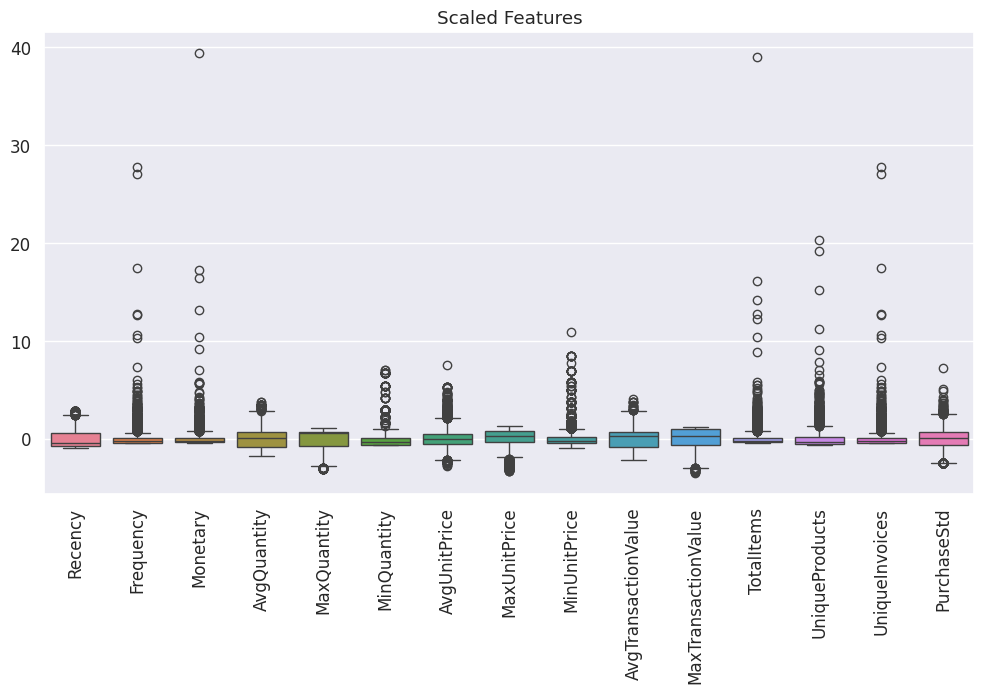

In [68]:
plt.figure(figsize=(12,6))

sns.boxplot(data=X_scaled)

plt.xticks(rotation=90)

plt.title("Scaled Features")

plt.show()

#### Apply PCA (All Components)

In [69]:
pca = PCA()

pca.fit(X_scaled)

print("PCA Model Created")

PCA Model Created


#### Explained Variance Ratio

In [70]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([3.32702711e-01, 2.06615820e-01, 1.31617465e-01, 1.28102871e-01,
       5.43353744e-02, 4.24258206e-02, 2.78737004e-02, 2.19556707e-02,
       1.81489743e-02, 1.33549426e-02, 1.07948819e-02, 7.23298438e-03,
       3.82429963e-03, 1.01448451e-03, 5.54977621e-17])

#### Explained Variance Table

In [71]:
variance_df = pd.DataFrame({

    "Principal Component":

    np.arange(1,len(explained_variance)+1),

    "Explained Variance":

    explained_variance

})

variance_df

,Principal Component,Explained Variance
0,1,3.327027e-01
1,2,2.066158e-01
2,3,1.316175e-01
3,4,1.281029e-01
4,5,5.433537e-02
5,6,4.242582e-02
6,7,2.787370e-02
7,8,2.195567e-02
8,9,1.814897e-02
9,10,1.335494e-02


#### Cumulative Explained Variance

In [72]:
cumulative_variance = np.cumsum(explained_variance)

variance_df["Cumulative Variance"] = cumulative_variance

variance_df

,Principal Component,Explained Variance,Cumulative Variance
0,1,3.327027e-01,0.332703
1,2,2.066158e-01,0.539319
2,3,1.316175e-01,0.670936
3,4,1.281029e-01,0.799039
4,5,5.433537e-02,0.853374
5,6,4.242582e-02,0.895800
6,7,2.787370e-02,0.923674
7,8,2.195567e-02,0.945629
8,9,1.814897e-02,0.963778
9,10,1.335494e-02,0.977133


#### Scree Plot

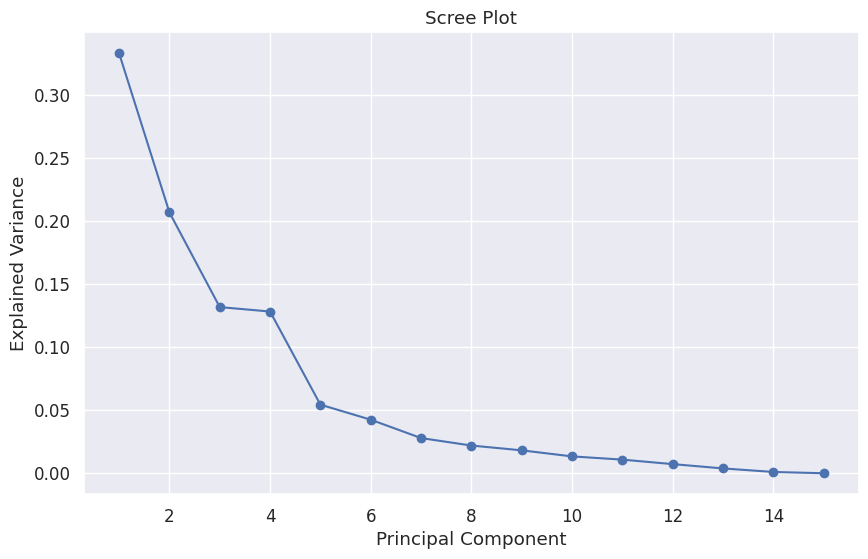

In [73]:
plt.figure(figsize=(10,6))

plt.plot(

    range(1,len(explained_variance)+1),

    explained_variance,

    marker='o'

)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance")

plt.title("Scree Plot")

plt.grid(True)

plt.show()

#### Cumulative Variance Plot

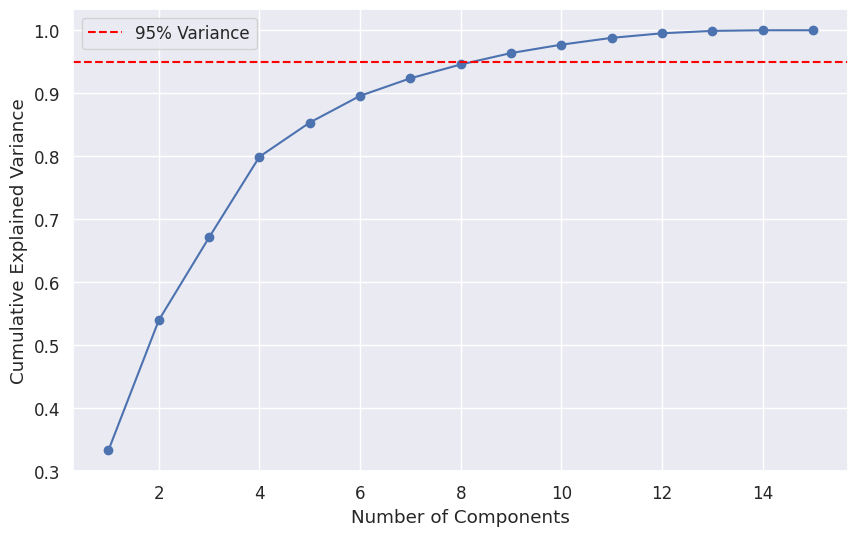

In [74]:
plt.figure(figsize=(10,6))

plt.plot(

    range(1,len(cumulative_variance)+1),

    cumulative_variance,

    marker='o'

)

plt.axhline(

    y=0.95,

    color='red',

    linestyle='--',

    label='95% Variance'

)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Explained Variance")

plt.legend()

plt.grid(True)

plt.show()

#### Determine Number of Components

In [75]:
n_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of Components for 95% Variance :", n_components)

Number of Components for 95% Variance : 9


#### Apply PCA Using Selected Components

In [76]:
pca_final = PCA(n_components=n_components)

X_pca = pca_final.fit_transform(X_scaled)

print("Reduced Shape :", X_pca.shape)

Reduced Shape : (4146, 9)


#### PCA Dataset

In [77]:
pca_columns = [

    f"PC{i+1}"

    for i in range(n_components)

]

pca_df = pd.DataFrame(

    X_pca,

    columns=pca_columns,

    index=X.index

)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
CustomerID,,,,,,,,,
12347.0,2.056605,1.046519,-0.210445,0.606203,-0.437575,-0.096932,-0.445198,-0.404736,-0.140844
12348.0,-2.569674,4.954661,3.443375,-3.396344,0.394246,-0.810864,0.268661,1.053239,-1.004780
12349.0,0.200205,-0.309469,-0.910234,0.496927,-0.883930,-1.273216,-0.075348,-0.392879,-0.018795
12350.0,-1.751456,1.736960,1.199304,-0.696098,1.681352,-0.537833,0.023205,0.375385,0.577228
12352.0,0.489277,-0.705314,0.392718,1.402888,-0.864197,-0.297858,0.382059,-0.010305,-0.740032


#### Verify Variance Retained

In [78]:
print("Variance Retained")

print(sum(pca_final.explained_variance_ratio_))

Variance Retained
0.9637784069655224


#### PCA Loadings

In [79]:
loadings = pd.DataFrame(

    pca_final.components_.T,

    columns=pca_columns,

    index=X.columns

)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
Recency,-0.190342,-0.045113,0.206351,0.037257,0.913131,-0.249183,0.057804,0.117725,-0.048933
Frequency,0.389428,-0.009917,0.245151,0.002733,0.022004,0.152611,0.505060,0.065551,-0.020296
Monetary,0.397041,0.001188,0.226967,0.007101,0.079185,-0.076105,-0.358839,-0.273903,0.080886
AvgQuantity,-0.014822,0.530689,0.083857,-0.028369,-0.023576,-0.208925,0.068020,-0.300156,-0.001379
MaxQuantity,0.195629,0.307952,-0.333465,-0.088921,0.000496,-0.459202,0.160380,0.316396,0.571726
MinQuantity,-0.144524,0.379522,0.353621,-0.130440,-0.140933,-0.046098,-0.061824,0.334421,-0.441668
AvgUnitPrice,-0.038529,-0.276795,0.087220,0.574268,-0.088443,-0.163880,0.108573,0.029796,0.009372
MaxUnitPrice,0.206211,-0.286791,-0.315720,0.262941,-0.034706,-0.400431,0.073140,-0.135466,-0.351671
MinUnitPrice,-0.181625,-0.078087,0.424571,0.393157,-0.142360,0.097353,-0.161827,0.262832,0.479151
AvgTransactionValue,-0.037749,0.390118,0.164580,0.435657,-0.079760,-0.201061,0.059704,-0.246435,-0.102509


#### Visualize Feature Contributions

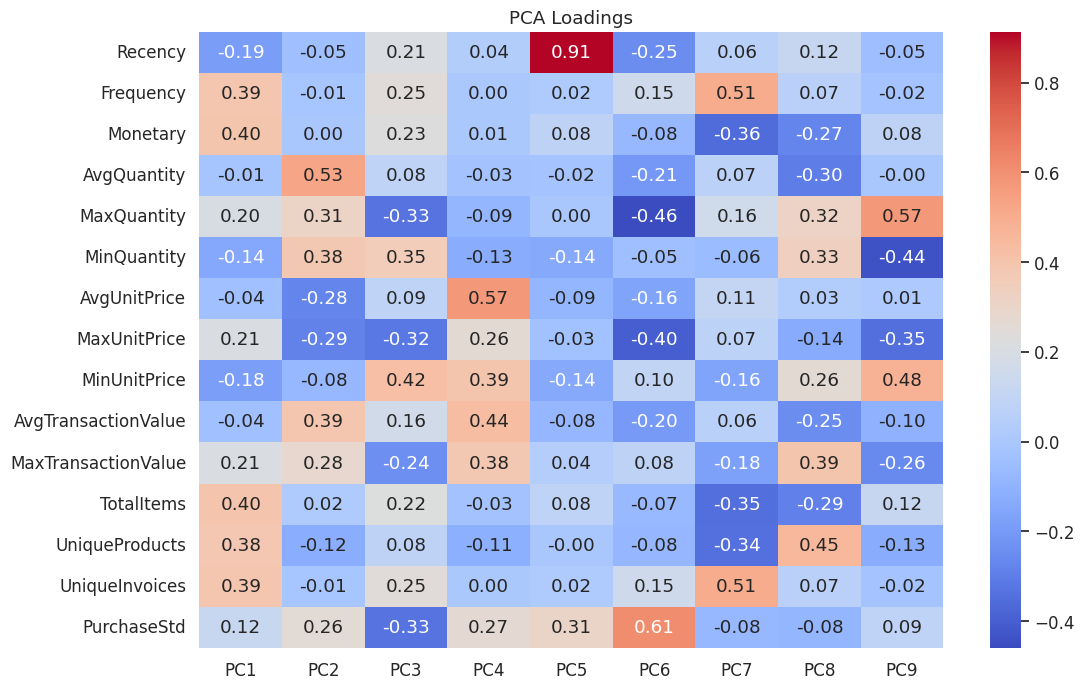

In [80]:
plt.figure(figsize=(12,8))

sns.heatmap(

    loadings,

    cmap="coolwarm",

    annot=True,

    fmt=".2f"

)

plt.title("PCA Loadings")

plt.show()

#### Create 2D PCA Data

In [83]:

# Use the first two principal components from the already
# computed PCA output (X_pca)

pca2_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=customer_df.index
)

print(pca2_df.head())

                 PC1       PC2
CustomerID                    
12347.0     2.056605  1.046519
12348.0    -2.569674  4.954661
12349.0     0.200205 -0.309469
12350.0    -1.751456  1.736960
12352.0     0.489277 -0.705314


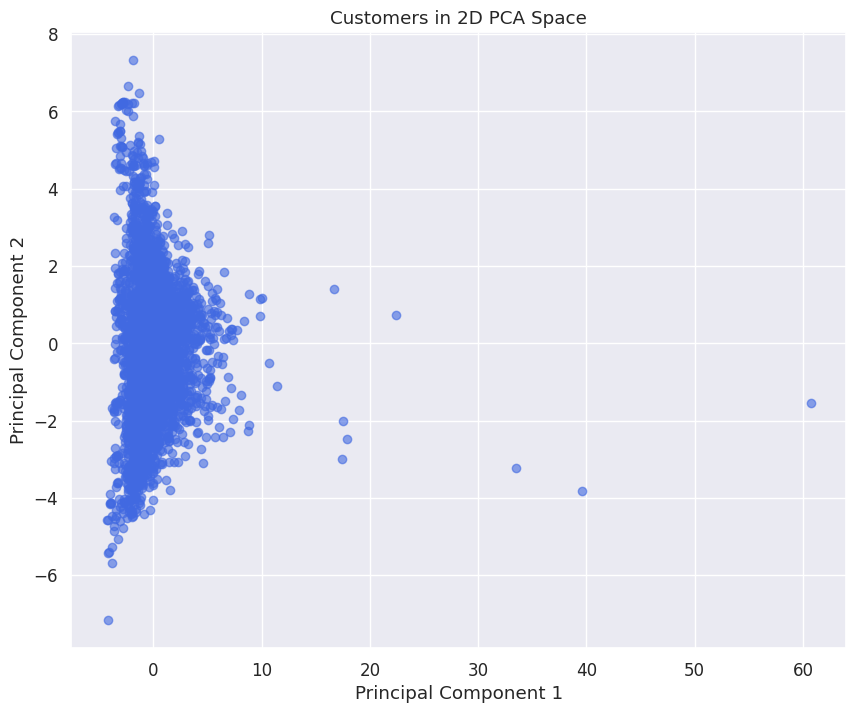

In [84]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca2_df["PC1"],
    pca2_df["PC2"],
    alpha=0.6,
    color="royalblue"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customers in 2D PCA Space")

plt.grid(True)

plt.show()

#### Create 3D PCA Data

In [89]:
if X_pca.shape[1] >= 3:

    pca3_df = pd.DataFrame(
        X_pca[:, :3],
        columns=["PC1","PC2","PC3"],
        index=customer_df.index
    )

else:

    pca_3d = PCA(n_components=3)

    X_pca_3d = pca_3d.fit_transform(X_scaled)

    pca3_df = pd.DataFrame(
        X_pca_3d,
        columns=["PC1","PC2","PC3"],
        index=customer_df.index
    )

print(pca3_df.head())

                 PC1       PC2       PC3
CustomerID                              
12347.0     2.056605  1.046519 -0.210445
12348.0    -2.569674  4.954661  3.443375
12349.0     0.200205 -0.309469 -0.910234
12350.0    -1.751456  1.736960  1.199304
12352.0     0.489277 -0.705314  0.392718


#### 3D PCA Visualization

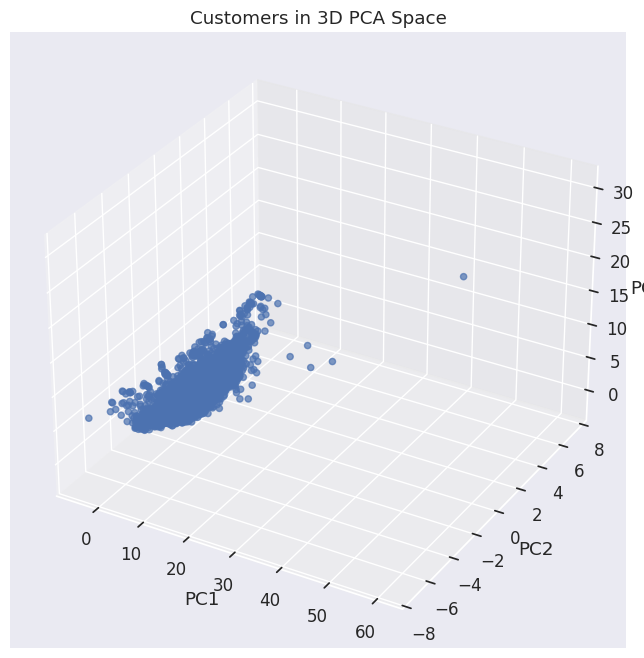

In [90]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(

    pca3_df["PC1"],

    pca3_df["PC2"],

    pca3_df["PC3"],

    alpha=0.7

)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("Customers in 3D PCA Space")

plt.show()

#### Summary

In [91]:
print("="*60)
print("PART 4 COMPLETED")
print("="*60)

print(f"""
Original Features            : {X.shape[1]}
Reduced Features (95% PCA)   : {n_components}
Variance Retained            : {sum(pca_final.explained_variance_ratio_):.4f}

PCA successfully reduced the dimensionality while preserving
at least 95% of the information in the data.
""")

PART 4 COMPLETED

Original Features            : 15
Reduced Features (95% PCA)   : 9
Variance Retained            : 0.9638

PCA successfully reduced the dimensionality while preserving
at least 95% of the information in the data.



## PART 5 : K-Means Clustering & Business Insights

#### Elbow Method

In [92]:
wcss = []

K = range(2,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_pca)

    wcss.append(model.inertia_)

#### Plot Elbow Curve

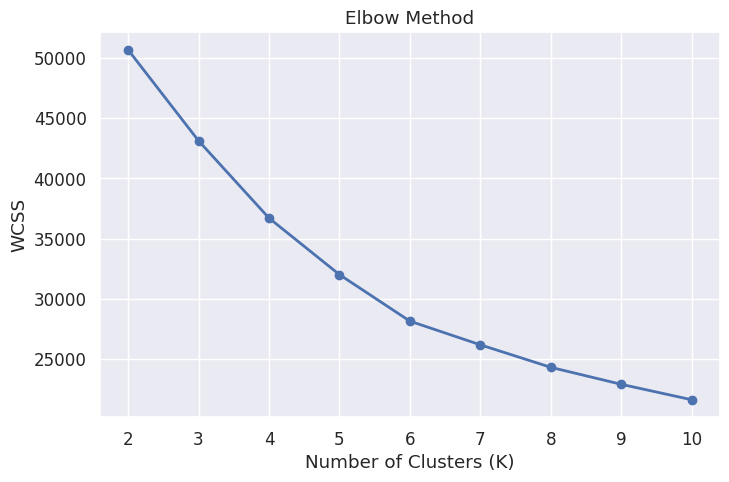

In [93]:
plt.figure(figsize=(8,5))

plt.plot(K,wcss,'bo-',linewidth=2)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

#### Silhouette Score

In [94]:
silhouette_scores=[]

for k in range(2,11):

    model=KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels=model.fit_predict(X_pca)

    score=silhouette_score(X_pca,labels)

    silhouette_scores.append(score)

    print(f"K={k}  Silhouette Score={score:.4f}")

K=2  Silhouette Score=0.2188
K=3  Silhouette Score=0.2257
K=4  Silhouette Score=0.2334
K=5  Silhouette Score=0.2344
K=6  Silhouette Score=0.2501
K=7  Silhouette Score=0.2241
K=8  Silhouette Score=0.2084
K=9  Silhouette Score=0.1814
K=10  Silhouette Score=0.1870


#### Silhouette Plot

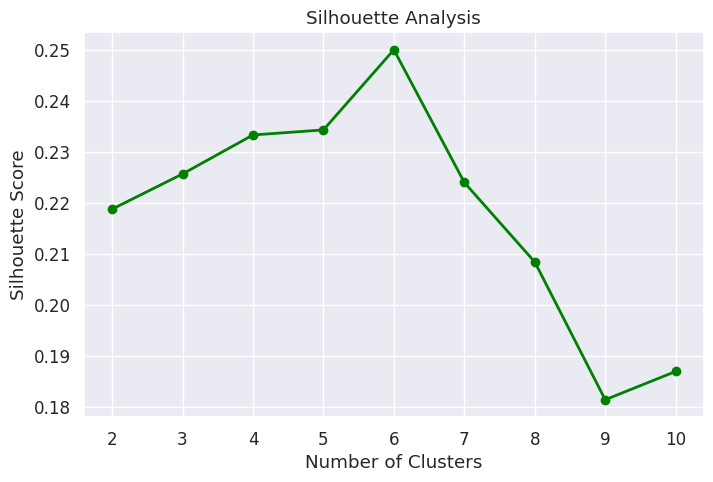

In [95]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker='o',
    linewidth=2,
    color='green'
)

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

#### Best K

In [96]:
best_k=np.argmax(silhouette_scores)+2

print("Best Number of Clusters :",best_k)

Best Number of Clusters : 6


#### Train Final Model

In [97]:
kmeans=KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters=kmeans.fit_predict(X_pca)

#### Add Cluster Labels

In [98]:
customer_df["Cluster"]=clusters

customer_df.head()

,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd,Cluster
CustomerID,,,,,,,,,,,,,,,,
12347.0,2,7,2783.37,10.974194,24,3,2.300903,5.95,0.25,17.957226,35.70,1701,93,7,7.068553,0
12348.0,249,3,90.20,23.333333,24,20,0.650000,0.85,0.55,15.033333,20.40,140,6,3,3.036884,5
12349.0,19,1,939.75,8.964912,25,2,2.566667,7.50,0.42,16.486842,27.04,511,57,1,4.725995,0
12350.0,310,1,294.40,12.250000,24,6,1.581250,2.95,0.85,18.400000,25.20,196,16,1,5.214211,5
12352.0,36,7,1130.94,7.575758,16,2,3.125152,6.25,0.65,17.135455,35.70,500,49,7,3.703872,0


#### Cluster Size

In [99]:
cluster_size=customer_df["Cluster"].value_counts().sort_index()

print(cluster_size)

Cluster
0    2006
1     886
2       3
3     381
4     459
5     411
Name: count, dtype: int64


#### Cluster Distribution

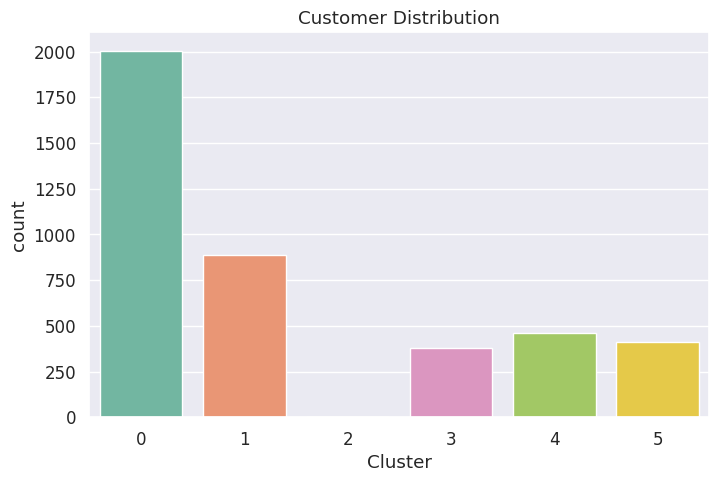

In [100]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Cluster",
    data=customer_df,
    palette="Set2"
)

plt.title("Customer Distribution")

plt.show()

#### 2D PCA Visualization

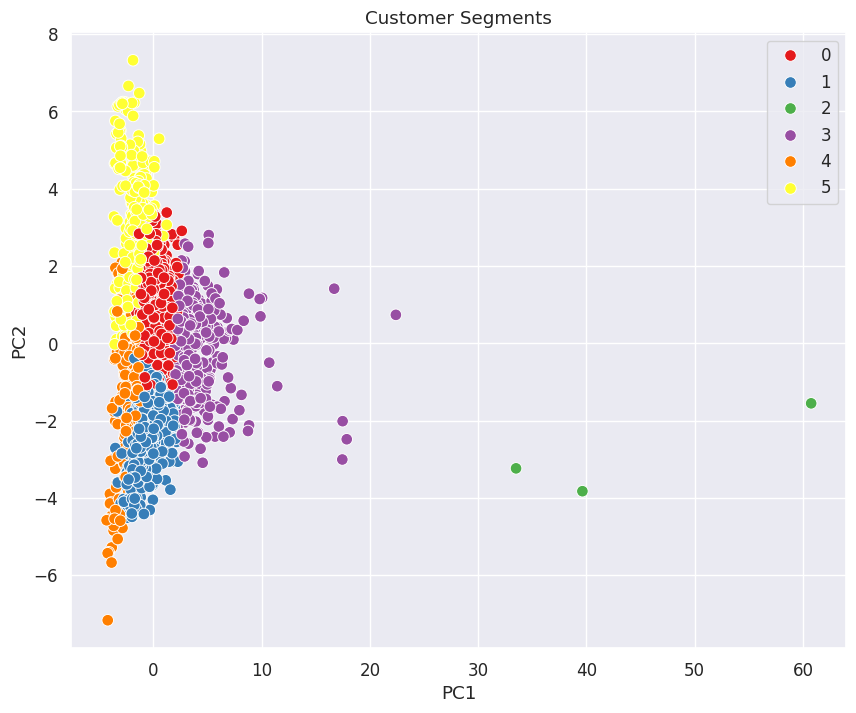

In [101]:
plt.figure(figsize=(10,8))

sns.scatterplot(

    x=pca2_df["PC1"],

    y=pca2_df["PC2"],

    hue=clusters,

    palette="Set1",

    s=70

)

plt.title("Customer Segments")

plt.show()

#### Plot Cluster Centers

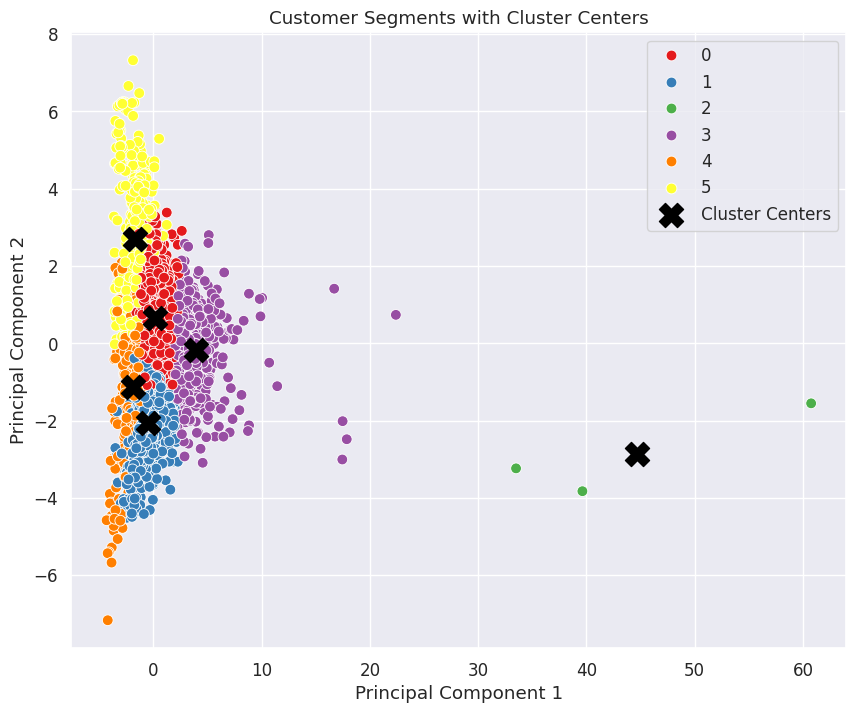

In [103]:
# Get cluster centers from the trained KMeans model
centers = kmeans.cluster_centers_

plt.figure(figsize=(10,8))

# Plot customers
sns.scatterplot(
    x=pca2_df["PC1"],
    y=pca2_df["PC2"],
    hue=clusters,
    palette="Set1",
    s=60
)

# Plot cluster centers
plt.scatter(
    centers[:,0],
    centers[:,1],
    color="black",
    marker="X",
    s=300,
    label="Cluster Centers"
)

plt.title("Customer Segments with Cluster Centers")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

#### 3D Cluster Visualization

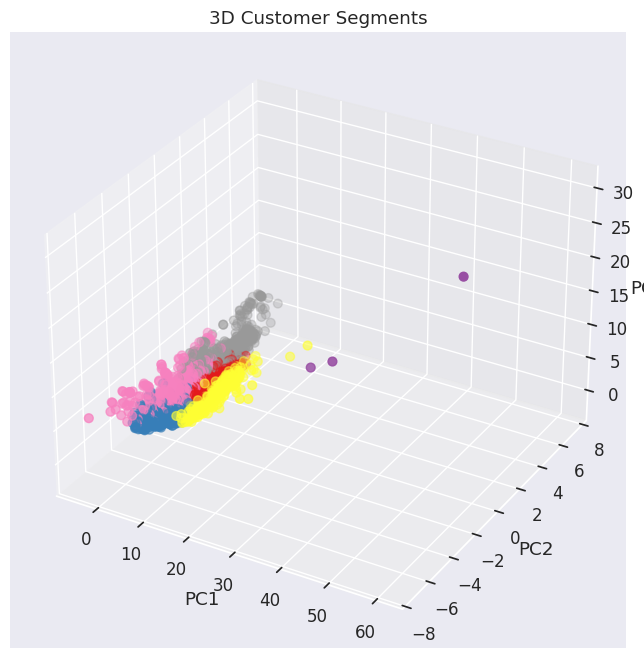

In [104]:
fig=plt.figure(figsize=(10,8))

ax=fig.add_subplot(111,projection='3d')

scatter=ax.scatter(

    pca3_df["PC1"],

    pca3_df["PC2"],

    pca3_df["PC3"],

    c=clusters,

    cmap='Set1',

    s=40

)

ax.set_xlabel("PC1")

ax.set_ylabel("PC2")

ax.set_zlabel("PC3")

plt.title("3D Customer Segments")

plt.show()

#### Cluster Summary

In [105]:
cluster_summary=customer_df.groupby("Cluster").mean()

cluster_summary

,Recency,Frequency,Monetary,AvgQuantity,MaxQuantity,MinQuantity,AvgUnitPrice,MaxUnitPrice,MinUnitPrice,AvgTransactionValue,MaxTransactionValue,TotalItems,UniqueProducts,UniqueInvoices,PurchaseStd
Cluster,,,,,,,,,,,,,,,
0,79.369890,3.393320,762.904688,10.349081,23.588235,2.561316,2.211131,5.808315,0.435665,15.958063,31.812024,496.072283,41.920738,3.393320,6.638695
1,99.498871,2.442438,378.797472,3.573159,16.659142,1.092551,2.132232,5.882438,0.377472,5.576897,20.953702,241.813770,63.159142,2.442438,4.334086
2,1.333333,168.000000,39736.473333,5.628838,26.000000,1.000000,2.087704,7.500000,0.086667,8.503595,37.480000,26170.000000,1436.333333,168.000000,5.461818
3,17.036745,14.314961,3601.261470,8.252212,24.454068,1.569554,2.107695,6.728766,0.259396,12.574468,34.523753,2355.023622,191.464567,14.314961,6.366968
4,172.191721,1.435730,171.547233,6.838063,10.962963,3.424837,3.259231,5.206754,1.771786,17.760228,25.087712,69.736383,9.557734,1.435730,4.320797
5,129.992701,1.598540,169.248029,15.363975,20.912409,9.941606,1.291424,2.208273,0.715450,17.000993,24.961727,162.586375,9.632603,1.598540,5.325807


#### Heatmap

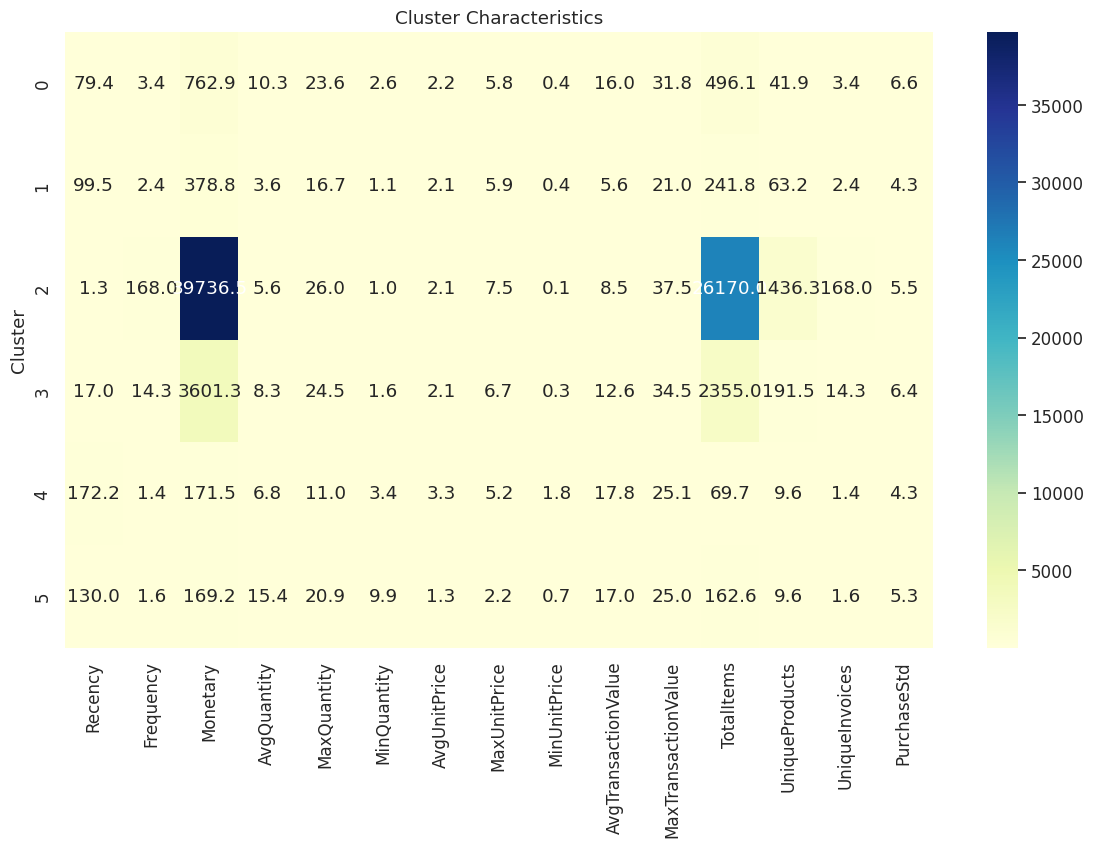

In [106]:
plt.figure(figsize=(14,8))

sns.heatmap(

    cluster_summary,

    annot=True,

    cmap="YlGnBu",

    fmt=".1f"

)

plt.title("Cluster Characteristics")

plt.show()

#### Radar Comparison

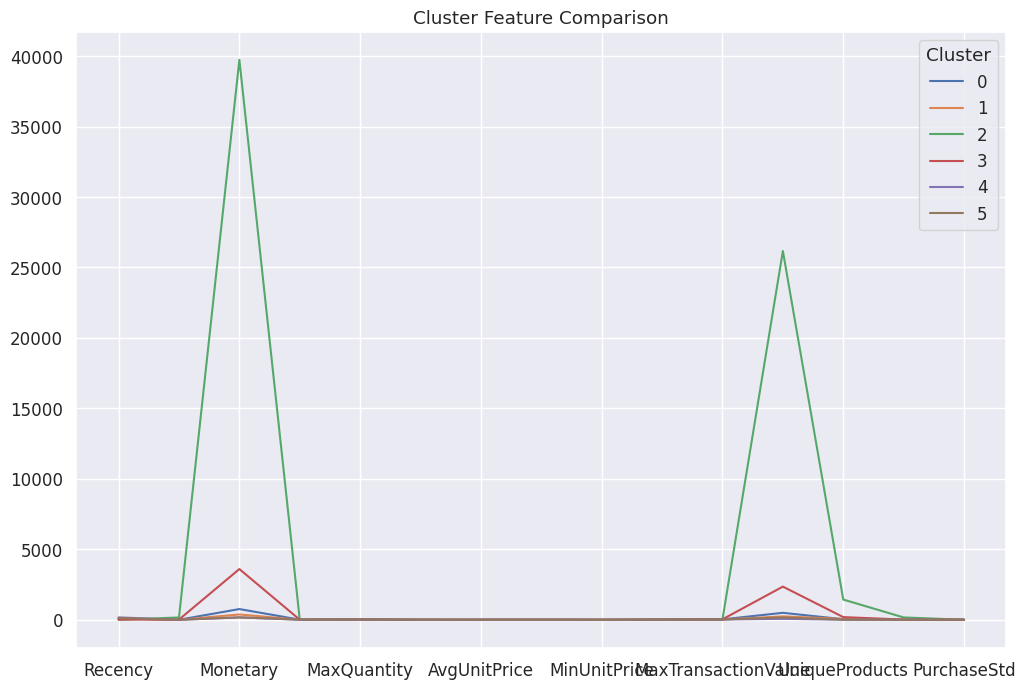

In [107]:
cluster_summary.T.plot(
    figsize=(12,8)
)

plt.title("Cluster Feature Comparison")

plt.grid(True)

plt.show()

#### Business Personas

In [108]:
print("="*70)
print("CUSTOMER PERSONAS")
print("="*70)

for cluster in sorted(customer_df["Cluster"].unique()):

    print(f"\nCluster {cluster}")

    data=customer_df[
        customer_df["Cluster"]==cluster
    ]

    print("Customers :",len(data))

    print("Average Recency :",round(data["Recency"].mean(),2))

    print("Average Frequency :",round(data["Frequency"].mean(),2))

    print("Average Monetary :",round(data["Monetary"].mean(),2))

    if data["Monetary"].mean()>customer_df["Monetary"].mean():

        print("Persona : High Value Customers")

    elif data["Frequency"].mean()>customer_df["Frequency"].mean():

        print("Persona : Loyal Customers")

    else:

        print("Persona : Budget Customers")

CUSTOMER PERSONAS

Cluster 0
Customers : 2006
Average Recency : 79.37
Average Frequency : 3.39
Average Monetary : 762.9
Persona : Budget Customers

Cluster 1
Customers : 886
Average Recency : 99.5
Average Frequency : 2.44
Average Monetary : 378.8
Persona : Budget Customers

Cluster 2
Customers : 3
Average Recency : 1.33
Average Frequency : 168.0
Average Monetary : 39736.47
Persona : High Value Customers

Cluster 3
Customers : 381
Average Recency : 17.04
Average Frequency : 14.31
Average Monetary : 3601.26
Persona : High Value Customers

Cluster 4
Customers : 459
Average Recency : 172.19
Average Frequency : 1.44
Average Monetary : 171.55
Persona : Budget Customers

Cluster 5
Customers : 411
Average Recency : 129.99
Average Frequency : 1.6
Average Monetary : 169.25
Persona : Budget Customers


#### Business Recommendations

In [109]:
print("="*70)
print("BUSINESS RECOMMENDATIONS")
print("="*70)

for cluster in sorted(customer_df["Cluster"].unique()):

    data=customer_df[
        customer_df["Cluster"]==cluster
    ]

    print("\n")

    print("Cluster",cluster)

    if data["Monetary"].mean()>customer_df["Monetary"].mean():

        print("Recommendation")

        print("- Premium Membership")

        print("- VIP Discounts")

        print("- Loyalty Rewards")

        print("- Exclusive Offers")

    elif data["Frequency"].mean()>customer_df["Frequency"].mean():

        print("Recommendation")

        print("- Reward Points")

        print("- Cross Selling")

        print("- Personalized Emails")

        print("- Membership Plans")

    else:

        print("Recommendation")

        print("- Coupons")

        print("- Festival Discounts")

        print("- Email Campaigns")

        print("- Cashback Offers")

BUSINESS RECOMMENDATIONS


Cluster 0
Recommendation
- Coupons
- Festival Discounts
- Email Campaigns
- Cashback Offers


Cluster 1
Recommendation
- Coupons
- Festival Discounts
- Email Campaigns
- Cashback Offers


Cluster 2
Recommendation
- Premium Membership
- VIP Discounts
- Loyalty Rewards
- Exclusive Offers


Cluster 3
Recommendation
- Premium Membership
- VIP Discounts
- Loyalty Rewards
- Exclusive Offers


Cluster 4
Recommendation
- Coupons
- Festival Discounts
- Email Campaigns
- Cashback Offers


Cluster 5
Recommendation
- Coupons
- Festival Discounts
- Email Campaigns
- Cashback Offers


#### Cluster-wise Customer Count

In [110]:
cluster_count=customer_df.groupby("Cluster").size()

cluster_percent=100*cluster_count/len(customer_df)

summary=pd.DataFrame({

    "Customers":cluster_count,

    "Percentage":cluster_percent.round(2)

})

summary

,Customers,Percentage
Cluster,,
0,2006,48.38
1,886,21.37
2,3,0.07
3,381,9.19
4,459,11.07
5,411,9.91


#### Save Final Dataset

In [111]:
customer_df.to_csv(
    "Final_Customer_Segments.csv"
)

print("Dataset Saved Successfully!")

Dataset Saved Successfully!


#### Final Conclusion

In [112]:
print("="*70)

print("PROJECT SUMMARY")

print("="*70)

print(f"""

Original Customers           : {len(customer_df)}

Optimal Clusters             : {best_k}

Variance Retained (PCA)      : {sum(pca_final.explained_variance_ratio_):.2%}

Best Silhouette Score        : {max(silhouette_scores):.4f}

------------------------------------------------

Workflow Completed

✔ Data Cleaning

✔ Feature Engineering

✔ Customer Dataset Creation

✔ Standardization

✔ PCA

✔ Elbow Method

✔ Silhouette Score

✔ KMeans Clustering

✔ Cluster Visualization

✔ Business Personas

✔ Business Recommendations

------------------------------------------------

Conclusion

Customer segmentation successfully divided the customers
into meaningful groups based on purchasing behaviour.

These customer groups can be used for

• Personalized Marketing

• Customer Retention

• Product Recommendation

• Loyalty Programs

• Business Growth

""")

PROJECT SUMMARY


Original Customers           : 4146

Optimal Clusters             : 6

Variance Retained (PCA)      : 96.38%

Best Silhouette Score        : 0.2501

------------------------------------------------

Workflow Completed

✔ Data Cleaning

✔ Feature Engineering

✔ Customer Dataset Creation

✔ Standardization

✔ PCA

✔ Elbow Method

✔ Silhouette Score

✔ KMeans Clustering

✔ Cluster Visualization

✔ Business Personas

✔ Business Recommendations

------------------------------------------------

Conclusion

Customer segmentation successfully divided the customers
into meaningful groups based on purchasing behaviour.

These customer groups can be used for

• Personalized Marketing

• Customer Retention

• Product Recommendation

• Loyalty Programs

• Business Growth


